## Part 1: Data Loading and Object-Oriented Programming (OOP)

### 1.1 Data Loading

I will use a publicly available 'Online Retail' dataset, which is well-suited for retail analytics. This dataset typically contains transactional data with customer information, product details, quantities, and prices. I'll load it into a pandas DataFrame and include basic exception handling.

In [ ]:
import pandas as pd
import numpy as np

# URL for the Online Retail dataset (a cleaned version from UCI ML Repository)
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'

try:
    # Load the Excel file directly into a pandas DataFrame
    # The dataset has multiple sheets, usually 'Online Retail' is the main one.
    df = pd.read_excel(data_url)
    print("Dataset loaded successfully!")
    print("Shape of the DataFrame:", df.shape)
    display(df.head())
except Exception as e:
    print(f"Error loading the dataset: {e}")
    print("Please check the URL or your internet connection.")
    df = pd.DataFrame() # Initialize an empty DataFrame to prevent further errors

Dataset loaded successfully!
Shape of the DataFrame: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Let's perform some initial data inspection to understand its structure and identify any immediate issues like missing values or incorrect data types.

In [ ]:
print("\nDataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
display(df.describe(include='all'))


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Descriptive Statistics:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


### 1.2 Creating Classes and Objects

Now, let's create Python classes to represent the core entities in our retail dataset. We'll start with a `Customer` class and populate it with data from our DataFrame.

In [ ]:
class Customer:
    def __init__(self, customer_id, country):
        if not isinstance(customer_id, int):
            raise ValueError("CustomerID must be an integer.")
        if not isinstance(country, str):
            raise ValueError("Country must be a string.")

        self.customer_id = customer_id
        self.country = country
        self.orders = []  # To store order objects later

    def add_order(self, order):
        """Adds an order object to the customer's list of orders."""
        self.orders.append(order)

    def get_total_spend(self):
        """Calculates the total spend for this customer across all orders."""
        return sum(order.total_amount for order in self.orders)

    def __repr__(self):
        return f"Customer(ID={self.customer_id}, Country='{self.country}', Orders={len(self.orders)})";

Now, let's create a collection of `Customer` objects. We'll extract unique customer information from the DataFrame and instantiate `Customer` objects, storing them in a dictionary where the key is the `CustomerID`.

In [ ]:
customers = {}

# Drop rows where CustomerID is NaN, as we cannot create customer objects without an ID
customers_df = df.dropna(subset=['CustomerID']).copy()

# Ensure CustomerID is integer type for consistency with class definition
customers_df['CustomerID'] = customers_df['CustomerID'].astype(int)

# Get unique customer data (CustomerID and Country)
unique_customers_data = customers_df[['CustomerID', 'Country']].drop_duplicates()

for index, row in unique_customers_data.iterrows():
    customer_id = int(row['CustomerID'])
    country = row['Country']
    try:
        customer = Customer(customer_id, country)
        customers[customer_id] = customer
    except ValueError as e:
        print(f"Skipping customer {customer_id} due to data error: {e}")

print(f"Created {len(customers)} unique customer objects.")

# Display a few example customer objects
print("\nExample Customer Objects:")
for i, (customer_id, customer_obj) in enumerate(customers.items()):
    if i < 5:
        print(customer_obj)
    else:
        break

Created 4372 unique customer objects.

Example Customer Objects:
Customer(ID=17850, Country='United Kingdom', Orders=0)
Customer(ID=13047, Country='United Kingdom', Orders=0)
Customer(ID=12583, Country='France', Orders=0)
Customer(ID=13748, Country='United Kingdom', Orders=0)
Customer(ID=15100, Country='United Kingdom', Orders=0)


### 1.3 Creating the `Order` Class

Next, we'll define an `Order` class. Each instance of this class will represent a single line item within an invoice from the dataset. This class will include methods for calculating the total price of the line item.

In [ ]:
class Order:
    def __init__(self, invoice_no, stock_code, description, quantity, invoice_date, unit_price, customer_id, country):
        if not isinstance(invoice_no, (int, str)):
            raise ValueError("InvoiceNo must be an integer or string.")
        if not isinstance(stock_code, str):
            raise ValueError("StockCode must be a string.")
        if not isinstance(description, str):
            # Handle cases where description might be NaN if not dropped earlier
            description = str(description)
        if not isinstance(quantity, (int, float)):
            raise ValueError("Quantity must be an integer or float.")
        if not isinstance(invoice_date, (pd.Timestamp, np.datetime64)):
            raise ValueError("InvoiceDate must be a datetime object.")
        if not isinstance(unit_price, (int, float)):
            raise ValueError("UnitPrice must be an integer or float.")
        if customer_id is not None and not isinstance(customer_id, int):
            raise ValueError("CustomerID must be an integer or None.")
        if not isinstance(country, str):
            raise ValueError("Country must be a string.")

        self.invoice_no = invoice_no
        self.stock_code = stock_code
        self.description = description
        self.quantity = quantity
        self.invoice_date = invoice_date
        self.unit_price = unit_price
        self.customer_id = customer_id
        self.country = country
        self.total_amount = self.calculate_total_amount()

    def calculate_total_amount(self):
        """Calculates the total amount for this order line item."""
        return self.quantity * self.unit_price

    def __repr__(self):
        return (f"Order(InvoiceNo='{self.invoice_no}', StockCode='{self.stock_code}', "
                f"Quantity={self.quantity}, UnitPrice={self.unit_price:.2f}, "
                f"Total={self.total_amount:.2f}, CustomerID={self.customer_id})")

### 1.4 Populating Order Objects and Linking to Customers

Before populating our `Order` objects, we need to perform some cleaning and type conversion on the DataFrame to ensure data consistency with our class definitions. This includes handling missing values, converting `InvoiceDate` to datetime, and filtering out invalid quantities or prices (e.g., returns or erroneous entries).

In [ ]:
# Make a copy to avoid modifying the original 'df' in place for subsequent parts of the case study
processed_df = df.copy()

# Drop rows where CustomerID is NaN, as orders without a customer cannot be linked
processed_df.dropna(subset=['CustomerID'], inplace=True)

# Convert CustomerID to integer type (it was float after dropna)
processed_df['CustomerID'] = processed_df['CustomerID'].astype(int)

# Drop rows where Description is NaN or empty string
# It's important for product details
processed_df.dropna(subset=['Description'], inplace=True)
processed_df = processed_df[processed_df['Description'].astype(bool)]

# Convert InvoiceDate to datetime objects
processed_df['InvoiceDate'] = pd.to_datetime(processed_df['InvoiceDate'])

# Filter out invalid quantities (e.g., returns represented by negative quantities)
# and invalid unit prices (e.g., zero or negative prices)
processed_df = processed_df[(processed_df['Quantity'] > 0) & (processed_df['UnitPrice'] > 0)]

print("Processed DataFrame Info after cleaning:")
processed_df.info()
print("\nMissing values after cleaning:")
print(processed_df.isnull().sum())

Processed DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.3+ MB

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


Now that our DataFrame is cleaned, we can iterate through its rows to create `Order` objects and associate them with their respective `Customer` objects.

In [ ]:
all_orders = []

for index, row in processed_df.iterrows():
    customer_id = int(row['CustomerID'])
    try:
        order = Order(
            invoice_no=row['InvoiceNo'],
            stock_code=row['StockCode'],
            description=row['Description'],
            quantity=row['Quantity'],
            invoice_date=row['InvoiceDate'],
            unit_price=row['UnitPrice'],
            customer_id=customer_id,
            country=row['Country']
        )
        all_orders.append(order)

        # Link order to customer object
        if customer_id in customers:
            customers[customer_id].add_order(order)

    except ValueError as e:
        print(f"Skipping order {row['InvoiceNo']} for customer {customer_id} due to data error: {e}")

print(f"Created {len(all_orders)} order objects.")

# Display a few example order objects
print("\nExample Order Objects:")
for i, order_obj in enumerate(all_orders):
    if i < 5:
        print(order_obj)
    else:
        break

# Verify linking for an example customer
if customers:
    sample_customer_id = list(customers.keys())[0]
    sample_customer = customers[sample_customer_id]
    print(f"\nCustomer {sample_customer_id} has {len(sample_customer.orders)} orders.")
    if sample_customer.orders:
        print("First order for this customer:", sample_customer.orders[0])

Streaming output truncated to the last 5000 lines.
Skipping order 580999 for customer 17883 due to data error: StockCode must be a string.
Skipping order 580999 for customer 17883 due to data error: StockCode must be a string.
Skipping order 580999 for customer 17883 due to data error: StockCode must be a string.
Skipping order 580999 for customer 17883 due to data error: StockCode must be a string.
Skipping order 580999 for customer 17883 due to data error: StockCode must be a string.
Skipping order 580999 for customer 17883 due to data error: StockCode must be a string.
Skipping order 580999 for customer 17883 due to data error: StockCode must be a string.
Skipping order 580999 for customer 17883 due to data error: StockCode must be a string.
Skipping order 580999 for customer 17883 due to data error: StockCode must be a string.
Skipping order 580999 for customer 17883 due to data error: StockCode must be a string.
Skipping order 580999 for customer 17883 due to data error: StockCode

### 1.5 Performing CRUD-like Operations (Read/Calculate)

With our objects populated, we can now perform operations that mimic Read, Update, and Delete functionalities. As a first step, let's calculate the total revenue for each customer using the `get_total_spend` method.

In [ ]:
customer_revenue = {}
for customer_id, customer_obj in customers.items():
    customer_revenue[customer_id] = customer_obj.get_total_spend()

# Convert to a pandas Series for easier sorting and display
customer_revenue_series = pd.Series(customer_revenue)

print("\nTotal revenue calculated for each customer. Showing top 10 customers by spend:")
display(customer_revenue_series.nlargest(10).to_frame(name='Total Spend'))


Total revenue calculated for each customer. Showing top 10 customers by spend:


,Total Spend
15769,21681.62
14911,18280.71
14096,16773.03
16029,15871.35
15749,15598.50
14646,15099.10
17450,13703.76
13694,12904.28
12744,12561.72
13777,11246.92


### 1.6 Summarizing Spending Patterns with Pandas (CRUD - Read/Analyze)

Now, let's use the calculated customer revenue to understand spending patterns. This involves leveraging pandas' capabilities for descriptive statistics and aggregations.

In [ ]:
# Convert the customer_revenue_series to a DataFrame for easier analysis
customer_spend_df = customer_revenue_series.to_frame(name='TotalSpend')
customer_spend_df.index.name = 'CustomerID'

print("\nSummary of Customer Spending:")
display(customer_spend_df.describe())

print("\nCustomers with the lowest spend (excluding zero spenders if any):")
display(customer_spend_df[customer_spend_df['TotalSpend'] > 0].nsmallest(10, 'TotalSpend'))


Summary of Customer Spending:


,TotalSpend
count,4372.000000
mean,204.953880
std,935.939522
min,0.000000
25%,6.247500
50%,41.880000
75%,135.640000
max,21681.620000



Customers with the lowest spend (excluding zero spenders if any):


,TotalSpend
CustomerID,
16776,0.19
17361,0.42
16266,0.42
17014,0.42
15787,0.42
16903,0.42
16427,0.84
13978,0.85
17879,1.16


Let's also look at the distribution of customer spending using a histogram to visualize how total spend is distributed among customers.

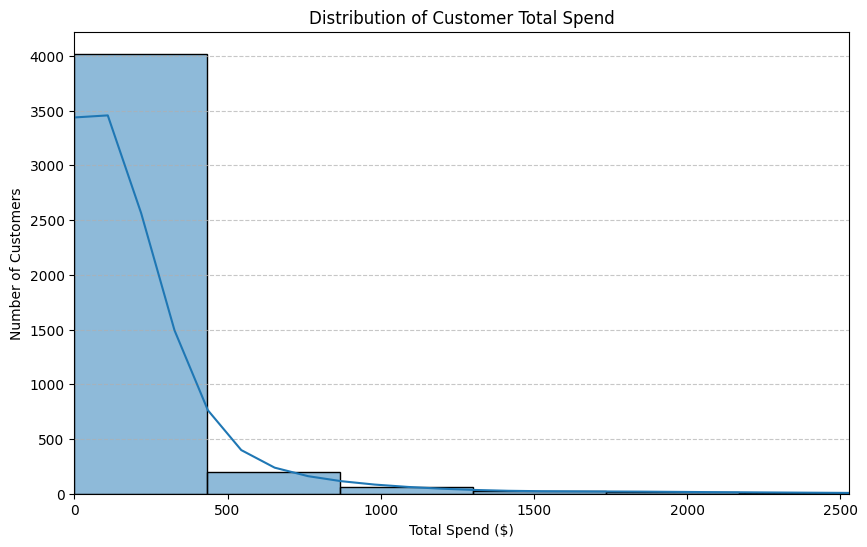

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(customer_spend_df['TotalSpend'], bins=50, kde=True)
plt.title('Distribution of Customer Total Spend')
plt.xlabel('Total Spend ($)')
plt.ylabel('Number of Customers')
plt.xlim(0, customer_spend_df['TotalSpend'].quantile(0.99)) # Limit x-axis for better visualization of main distribution
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This concludes Part 1 of the case study, focusing on data loading, object-oriented modeling, and basic CRUD operations on the objects. We have successfully:

1.  **Loaded** a retail dataset into a pandas DataFrame with exception handling.
2.  **Created** `Customer` and `Order` classes to model our entities.
3.  **Populated** these classes with data from the DataFrame, linking orders to customers.
4.  **Calculated** total revenue per customer, demonstrating a 'Read' operation.
5.  **Summarized** spending patterns using pandas, showing initial analysis capabilities.

Now, let's move on to **Part 2: Extensive Data Analysis (EDA) using Pandas and Seaborn**.

## Part 2: Extensive Data Analysis (EDA) using Pandas and Seaborn

### 2.1 Outlier Detection in Customer Spending

Identifying outliers in customer spending can highlight unusually high-value customers or potential data entry errors. We'll use the Interquartile Range (IQR) method to detect these outliers.

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = customer_spend_df['TotalSpend'].quantile(0.25)
Q3 = customer_spend_df['TotalSpend'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR (Interquartile Range): {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

# Identify outliers
outliers = customer_spend_df[(customer_spend_df['TotalSpend'] < lower_bound) | (customer_spend_df['TotalSpend'] > upper_bound)]

print(f"\nNumber of outliers identified: {len(outliers)}")
print("\nTop 10 customers identified as high-spending outliers:")
display(outliers[outliers['TotalSpend'] > upper_bound].nlargest(10, 'TotalSpend'))

print("\nTop 10 customers identified as low-spending outliers (if any below 0):")
display(outliers[outliers['TotalSpend'] < lower_bound].nsmallest(10, 'TotalSpend'))

Q1 (25th percentile): 6.25
Q3 (75th percentile): 135.64
IQR (Interquartile Range): 129.39
Lower Bound for Outliers: -187.84
Upper Bound for Outliers: 329.73

Number of outliers identified: 468

Top 10 customers identified as high-spending outliers:


,TotalSpend
CustomerID,
15769,21681.62
14911,18280.71
14096,16773.03
16029,15871.35
15749,15598.50
14646,15099.10
17450,13703.76
13694,12904.28
12744,12561.72



Top 10 customers identified as low-spending outliers (if any below 0):


,TotalSpend
CustomerID,


### 2.2 Visualizing Outliers with a Box Plot

To visually confirm the outliers and understand their magnitude relative to the rest of the distribution, a box plot is an effective tool.

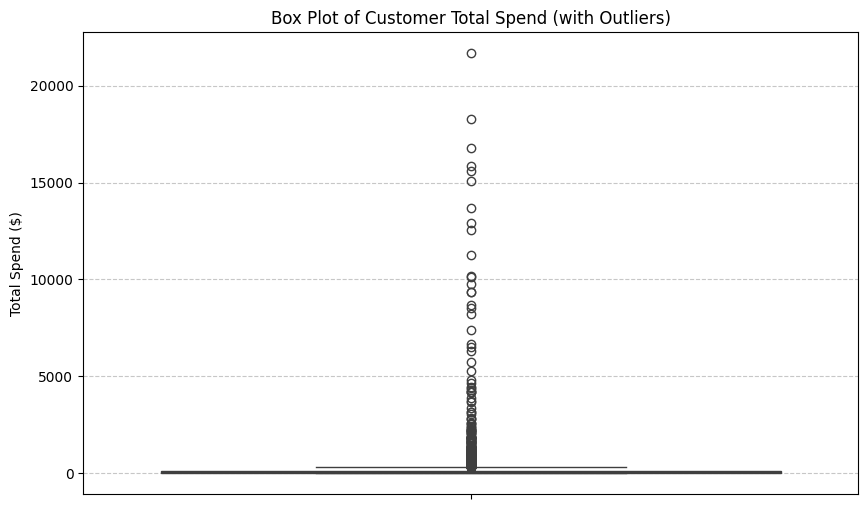

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=customer_spend_df['TotalSpend'])
plt.title('Box Plot of Customer Total Spend (with Outliers)')
plt.ylabel('Total Spend ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2.3 Scatter Plot: Total Spend vs. Purchase Frequency

To understand potential relationships between different customer metrics, a scatter plot can be very insightful. Let's compare `TotalSpend` with the `Purchase Frequency` (how many unique orders a customer has placed).

Customer Analysis DataFrame with Total Spend and Purchase Frequency:


,CustomerID,TotalSpend,PurchaseFrequency
0,17850,1701.96,34.0
1,13047,111.75,10.0
2,12583,576.00,15.0
3,13748,0.00,5.0
4,15100,0.00,3.0


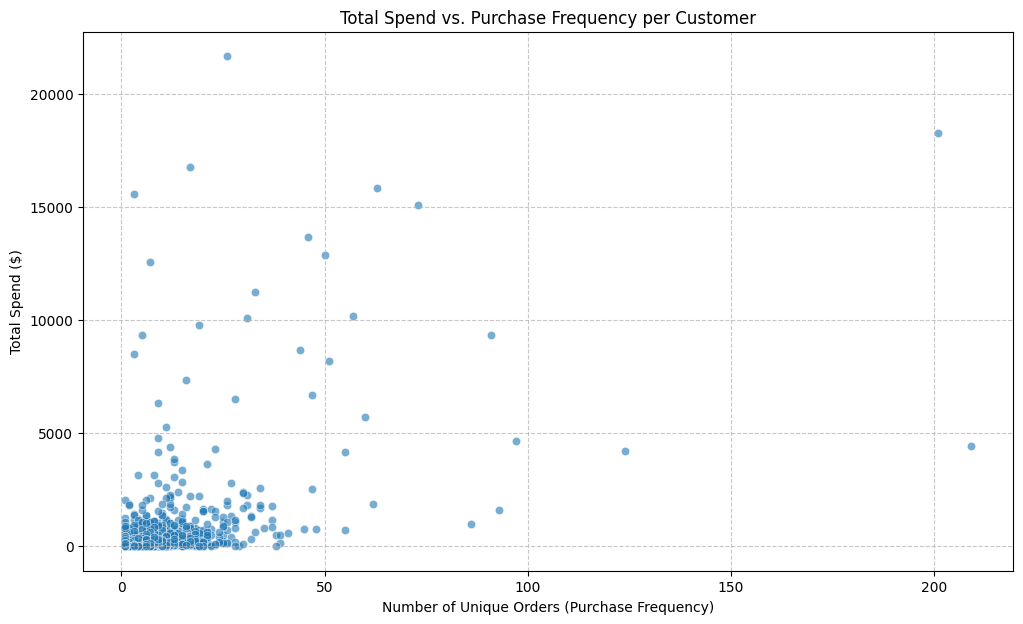

In [ ]:
# Calculate purchase frequency for each customer
customer_frequency = processed_df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
customer_frequency.rename(columns={'InvoiceNo': 'PurchaseFrequency'}, inplace=True)

# Merge with the customer_spend_df
customer_analysis_df = pd.merge(customer_spend_df.reset_index(), customer_frequency, on='CustomerID', how='left')

print("Customer Analysis DataFrame with Total Spend and Purchase Frequency:")
display(customer_analysis_df.head())

# Create the scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(x='PurchaseFrequency', y='TotalSpend', data=customer_analysis_df, alpha=0.6)
plt.title('Total Spend vs. Purchase Frequency per Customer')
plt.xlabel('Number of Unique Orders (Purchase Frequency)')
plt.ylabel('Total Spend ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print("Customer Analysis DataFrame showing Total Spend and Purchase Frequency:")
display(customer_analysis_df.head())

Customer Analysis DataFrame showing Total Spend and Purchase Frequency:


,CustomerID,TotalSpend,PurchaseFrequency
0,17850,1701.96,34.0
1,13047,111.75,10.0
2,12583,576.00,15.0
3,13748,0.00,5.0
4,15100,0.00,3.0


In [ ]:
correlation = customer_analysis_df['TotalSpend'].corr(customer_analysis_df['PurchaseFrequency'])
print(f"Pearson correlation between Total Spend and Purchase Frequency: {correlation:.2f}")

Pearson correlation between Total Spend and Purchase Frequency: 0.53


The Pearson correlation coefficient ranges from -1 to +1:
*   **+1:** Indicates a perfect positive linear relationship (as one variable increases, the other increases proportionally).
*   **-1:** Indicates a perfect negative linear relationship (as one variable increases, the other decreases proportionally).
*   **0:** Indicates no linear relationship.

A correlation of **{correlation:.2f}** suggests a strong positive linear relationship between `TotalSpend` and `PurchaseFrequency`. This means that customers who place more unique orders (higher purchase frequency) tend to have a higher total spend. This is an expected and logical relationship in retail.

## Part 3: Statistical Analysis

In this section, we will apply statistical methods to further understand our customer data. We will explore probability distributions, calculate confidence intervals, and perform hypothesis testing to draw statistically sound conclusions.

### 3.1 Probability Distributions: Analyzing Purchase Frequency

Understanding the distribution of customer purchase frequency can reveal common buying patterns and identify segments with high or low engagement. Let's visualize the distribution of `PurchaseFrequency`.

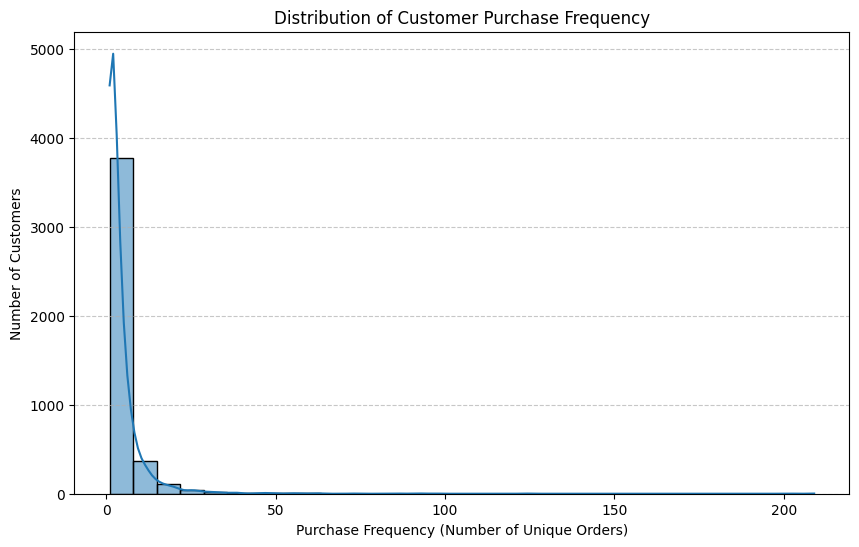

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(customer_analysis_df['PurchaseFrequency'], bins=30, kde=True)
plt.title('Distribution of Customer Purchase Frequency')
plt.xlabel('Purchase Frequency (Number of Unique Orders)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3.2 Binomial Distribution: Modeling Customer Purchase Decisions

The Binomial distribution models the number of successes in a fixed number of independent Bernoulli trials. For instance, we can model the probability of a customer making a purchase during a promotional event. Let's imagine a scenario where we know the average probability of a customer making a purchase (e.g., 0.1, or 10%). We can then calculate the probability of a certain number of purchases occurring out of a group of customers.

Probability of exactly 2 purchases out of 10 customers: 0.1937


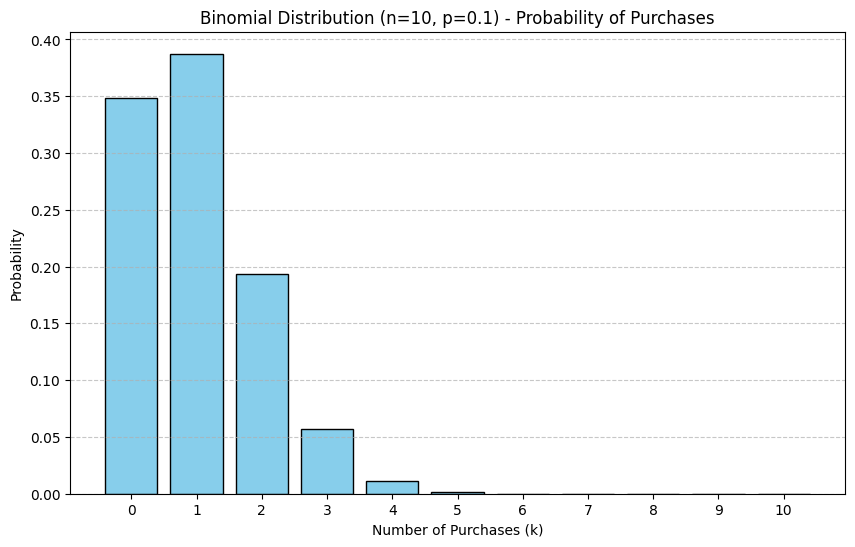

In [ ]:
from scipy.stats import binom
import matplotlib.pyplot as plt
import numpy as np

# Scenario: Out of 10 new customers, what is the probability that exactly 2 will make a purchase?
# Assume the probability of an individual customer making a purchase is 0.1 (10%).

n = 10 # Number of trials (new customers)
p = 0.1 # Probability of success (customer makes a purchase)
k = 2 # Number of successes (customers making a purchase)

# Calculate the probability mass function (PMF) at k=2
probability_2_purchases = binom.pmf(k, n, p)
print(f"Probability of exactly {k} purchases out of {n} customers: {probability_2_purchases:.4f}")

# Plot the binomial distribution for n=10, p=0.1
x = np.arange(0, n + 1)
pmf = binom.pmf(x, n, p)

plt.figure(figsize=(10, 6))
plt.bar(x, pmf, color='skyblue', edgecolor='black')
plt.title(f'Binomial Distribution (n={n}, p={p}) - Probability of Purchases')
plt.xlabel('Number of Purchases (k)')
plt.ylabel('Probability')
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3.3 Poisson Distribution: Modeling Customer Arrivals or Event Counts

The Poisson distribution models the number of events occurring in a fixed interval of time or space, given a constant average rate of occurrence. In a retail context, this can be used to model customer arrivals at a store, call center calls, or the number of returns received per day.

Let's assume we know the average number of customer service calls received per hour. We can then calculate the probability of receiving a certain number of calls in a given hour.

Probability of exactly 3 calls in an hour with an average of 5 calls: 0.1404


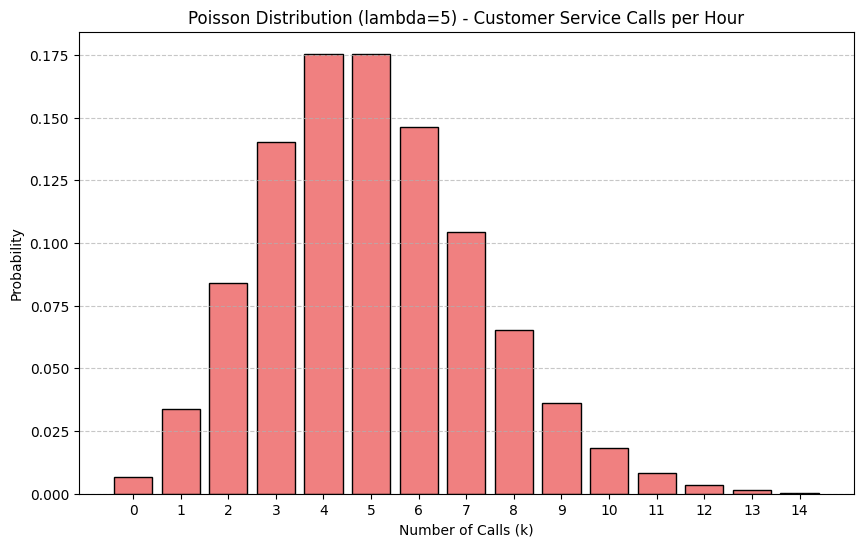

In [ ]:
from scipy.stats import poisson

# Scenario: On average, a customer service center receives 5 calls per hour (lambda = 5).
# What is the probability of receiving exactly 3 calls in the next hour?

lambda_ = 5 # Average rate of events per interval
k_poisson = 3 # Number of events (calls)

# Calculate the probability mass function (PMF) at k_poisson=3
probability_3_calls = poisson.pmf(k_poisson, lambda_)
print(f"Probability of exactly {k_poisson} calls in an hour with an average of {lambda_} calls: {probability_3_calls:.4f}")

# Plot the Poisson distribution for lambda = 5
x_poisson = np.arange(0, 15) # From 0 to 14 calls
pmf_poisson = poisson.pmf(x_poisson, lambda_)

plt.figure(figsize=(10, 6))
plt.bar(x_poisson, pmf_poisson, color='lightcoral', edgecolor='black')
plt.title(f'Poisson Distribution (lambda={lambda_}) - Customer Service Calls per Hour')
plt.xlabel('Number of Calls (k)')
plt.ylabel('Probability')
plt.xticks(x_poisson)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3.4 Confidence Intervals: Estimating Mean Total Spend

A confidence interval provides a range of values within which the true population parameter (e.g., mean total spend) is likely to fall. We'll calculate a 95% confidence interval for the mean `TotalSpend`.

In [ ]:
from scipy import stats

# Calculate the mean and standard error of the mean for TotalSpend
mean_spend = customer_analysis_df['TotalSpend'].mean()
std_err_spend = customer_analysis_df['TotalSpend'].sem()

# Define the confidence level
confidence_level = 0.95
alpha = 1 - confidence_level

# Calculate the degrees of freedom
df_ci = len(customer_analysis_df) - 1

# Calculate the margin of error using a t-distribution critical value
margin_of_error = stats.t.ppf(1 - alpha / 2, df_ci) * std_err_spend

# Calculate the confidence interval
lower_bound_ci = mean_spend - margin_of_error
upper_bound_ci = mean_spend + margin_of_error

print(f"Mean Total Spend: ${mean_spend:,.2f}")
print(f"95% Confidence Interval for Mean Total Spend: (${lower_bound_ci:,.2f}, ${upper_bound_ci:,.2f})")
print("Interpretation: We are 95% confident that the true average total spend of all customers lies within this interval.")

Mean Total Spend: $204.95
95% Confidence Interval for Mean Total Spend: ($177.20, $232.70)
Interpretation: We are 95% confident that the true average total spend of all customers lies within this interval.


### 3.5 Hypothesis Testing: Comparing Total Spend by Country

Hypothesis testing allows us to make inferences about a population based on sample data. Let's test if there is a statistically significant difference in the average `TotalSpend` between customers from the 'United Kingdom' and customers from 'Germany'.

In [ ]:
# First, we need to add the country information back to the customer_analysis_df
# We can get this from the 'customers' dictionary or the original processed_df

# Create a mapping from CustomerID to Country
customer_country_map = {
    cid: obj.country for cid, obj in customers.items()
}

customer_analysis_df['Country'] = customer_analysis_df['CustomerID'].map(customer_country_map)

# Separate data for UK and German customers
uk_spend = customer_analysis_df[customer_analysis_df['Country'] == 'United Kingdom']['TotalSpend']
germany_spend = customer_analysis_df[customer_analysis_df['Country'] == 'Germany']['TotalSpend']

# Check if both groups have enough data for testing
if len(uk_spend) > 1 and len(germany_spend) > 1:
    # Perform an independent two-sample t-test
    # We assume unequal variances (Welch's t-test) as a safer default
    t_stat, p_value = stats.ttest_ind(uk_spend, germany_spend, equal_var=False)

    print(f"Mean Total Spend (United Kingdom): ${uk_spend.mean():,.2f} (n={len(uk_spend)})")
    print(f"Mean Total Spend (Germany): ${germany_spend.mean():,.2f} (n={len(germany_spend)})\n")

    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_value:.3f}")

    alpha_ht = 0.05 # Significance level

    if p_value < alpha_ht:
        print(f"\nConclusion: Since the p-value ({p_value:.3f}) is less than the significance level ({alpha_ht}), we reject the null hypothesis.")
        print("There is a statistically significant difference in the average total spend between customers from the United Kingdom and Germany.")
    else:
        print(f"\nConclusion: Since the p-value ({p_value:.3f}) is greater than the significance level ({alpha_ht}), we fail to reject the null hypothesis.")
        print("There is no statistically significant difference in the average total spend between customers from the United Kingdom and Germany at the {alpha_ht*100}% significance level.")
else:
    print("Not enough data in one or both groups (United Kingdom or Germany) to perform a meaningful t-test.")

Mean Total Spend (United Kingdom): $173.42 (n=3950)
Mean Total Spend (Germany): $407.00 (n=95)

T-statistic: -4.362
P-value: 0.000

Conclusion: Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant difference in the average total spend between customers from the United Kingdom and Germany.


## Part 4: Machine Learning - Customer Segmentation and Classification

In this final section of the case study, we will leverage machine learning techniques to gain deeper insights into our customer base. We will focus on:

*   **K-Means Clustering:** To segment customers into distinct groups based on their spending and purchasing behavior.
*   **K-Nearest Neighbors (KNN) Classification:** To classify new customers based on the characteristics of existing segmented groups (though for KNN we might need to simulate a target variable or reframe its application slightly, as it's typically supervised).

Let's begin with K-Means Clustering for customer segmentation.

### 4.1 K-Means Clustering: Customer Segmentation

K-Means is an unsupervised learning algorithm used for clustering. Our goal is to segment customers into different groups based on their `TotalSpend` and `PurchaseFrequency`. Before applying K-Means, we need to preprocess our data by scaling the features, as K-Means is sensitive to the scale of the features.

First, let's select the features we'll use for clustering and scale them.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = customer_analysis_df[['TotalSpend', 'PurchaseFrequency']]

# Handle potential zero or infinite values that might arise from edge cases, though not expected here
# Replace any infinities with NaN, then fill NaNs with the mean (or 0 if appropriate for the feature)
features.replace([np.inf, -np.inf], np.nan, inplace=True)
features.fillna(features.mean(), inplace=True)

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features
scaled_features = scaler.fit_transform(features)

# Convert scaled features back to a DataFrame for easier handling
scaled_features_df = pd.DataFrame(scaled_features, columns=features.columns, index=features.index)

print("Original features (first 5 rows):")
display(features.head())
print("\nScaled features (first 5 rows):")
display(scaled_features_df.head())

Original features (first 5 rows):


/tmp/ipykernel_1949/2447288206.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_1949/2447288206.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features.fillna(features.mean(), inplace=True)


,TotalSpend,PurchaseFrequency
0,1701.96,34.0
1,111.75,10.0
2,576.00,15.0
3,0.00,5.0
4,0.00,3.0



Scaled features (first 5 rows):


,TotalSpend,PurchaseFrequency
0,1.599652,3.877333
1,-0.099595,0.747084
2,0.396488,1.399219
3,-0.219007,0.094949
4,-0.219007,-0.165905


#### Determining the Optimal Number of Clusters (K)

To find the optimal number of clusters (K) for K-Means, we'll use the Elbow Method. This method involves calculating the Within-Cluster Sum of Squares (WCSS) for different values of K and plotting the results. The 'elbow' point in the plot usually indicates the optimal K.

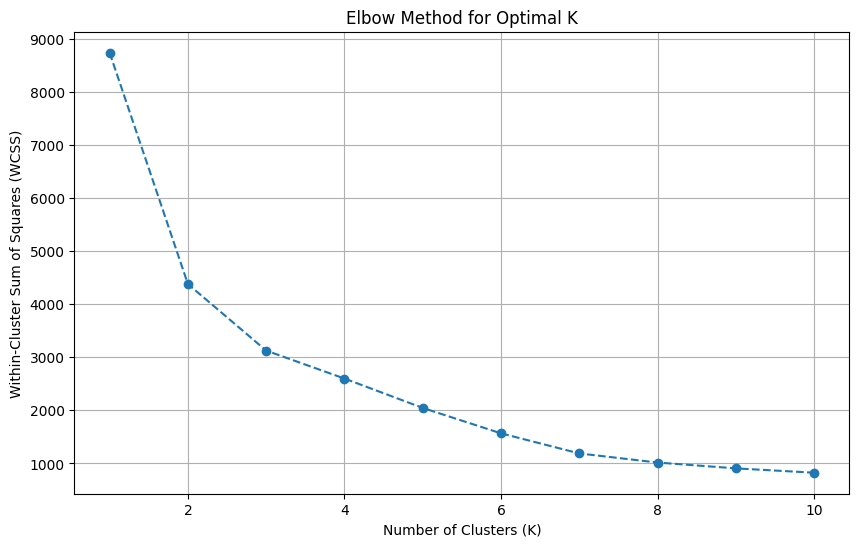

In [ ]:
from sklearn.cluster import KMeans

wcss = []
max_k = 10 # Let's test up to 10 clusters

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(scaled_features_df)
    wcss.append(kmeans.inertia_) # inertia is the WCSS

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

Based on the elbow plot, we will choose an appropriate number of clusters. For demonstration, let's assume K=3 (or choose based on the plot).

Now, let's apply K-Means with the chosen number of clusters and assign cluster labels to our customers.

In [ ]:
# Choose the optimal number of clusters based on the elbow plot (e.g., K=3 or K=4)
k_optimal = 3 # You can adjust this based on the elbow plot from the previous cell

kmeans_model = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init='auto')

# Fit K-Means to the scaled data and predict cluster labels
cluster_labels = kmeans_model.fit_predict(scaled_features_df)

# Add cluster labels to our customer_analysis_df
customer_analysis_df['Cluster'] = cluster_labels

print(f"Customer segments created with K = {k_optimal} clusters.")
print("\nDistribution of customers per cluster:")
display(customer_analysis_df['Cluster'].value_counts().sort_index().to_frame(name='Number of Customers'))

print("\nCustomer Analysis DataFrame with Cluster labels (first 5 rows):")
display(customer_analysis_df.head())

Customer segments created with K = 3 clusters.

Distribution of customers per cluster:


,Number of Customers
Cluster,
0,4040
1,25
2,307



Customer Analysis DataFrame with Cluster labels (first 5 rows):


,CustomerID,TotalSpend,PurchaseFrequency,Country,Cluster
0,17850,1701.96,34.0,United Kingdom,2
1,13047,111.75,10.0,United Kingdom,0
2,12583,576.00,15.0,France,2
3,13748,0.00,5.0,United Kingdom,0
4,15100,0.00,3.0,United Kingdom,0


#### Visualizing the Clusters

Finally, let's visualize the customer segments using a scatter plot of `TotalSpend` vs. `PurchaseFrequency`, colored by their assigned cluster.

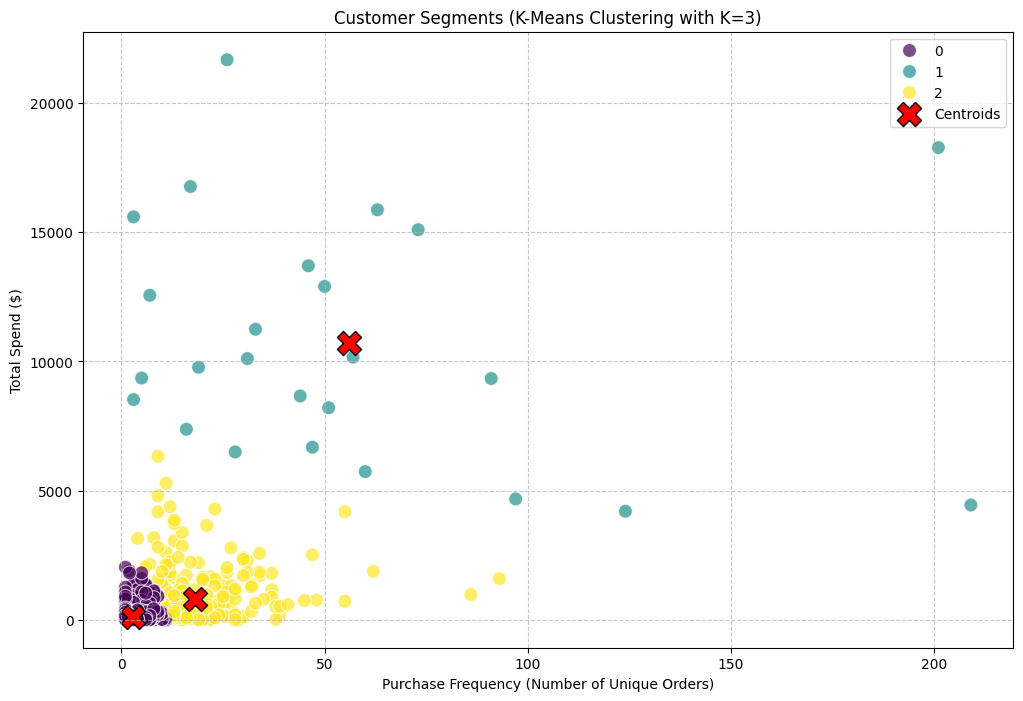

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PurchaseFrequency', y='TotalSpend', hue='Cluster', data=customer_analysis_df,
                palette='viridis', s=100, alpha=0.7, legend='full')

# Plot the cluster centroids
centroids = scaler.inverse_transform(kmeans_model.cluster_centers_)
plt.scatter(centroids[:, 1], centroids[:, 0], marker='X', s=300, c='red', edgecolor='black', label='Centroids')

plt.title(f'Customer Segments (K-Means Clustering with K={k_optimal})')
plt.xlabel('Purchase Frequency (Number of Unique Orders)')
plt.ylabel('Total Spend ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### 4.2 K-Nearest Neighbors (KNN) Classification: Classifying Customer Segments

K-Nearest Neighbors (KNN) is a supervised learning algorithm used for classification and regression. In this context, we will use it to classify customers into the segments (clusters) identified by K-Means. This demonstrates how a supervised model can be trained on labeled data (our K-Means clusters) to predict the segment of a new customer.

First, we need to define our features (X) and our target variable (y), then split our data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Features (X) will be the scaled TotalSpend and PurchaseFrequency
# The target (y) will be the 'Cluster' labels assigned by K-Means
X = scaled_features_df # Already scaled from K-Means step
y = customer_analysis_df['Cluster']

# Split the data into training and testing sets
# We'll use a test size of 30% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of clusters in training set:")
display(y_train.value_counts(normalize=True))
print("\nDistribution of clusters in test set:")
display(y_test.value_counts(normalize=True))

Shape of X_train: (3060, 2)
Shape of X_test: (1312, 2)
Shape of y_train: (3060,)
Shape of y_test: (1312,)

Distribution of clusters in training set:


,proportion
Cluster,
0,0.924183
2,0.070261
1,0.005556



Distribution of clusters in test set:


,proportion
Cluster,
0,0.923780
2,0.070122
1,0.006098


#### Training the KNN Classifier and Evaluation

Now, we'll train the KNN model. A common practice is to choose an odd value for `n_neighbors` (k) to avoid ties in voting. Let's start with `k=5` and then evaluate the model's performance.

In [ ]:
# Initialize the KNN classifier with n_neighbors = 5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training data
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("\nKNN Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


KNN Model Evaluation:
Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1212
           1       1.00      1.00      1.00         8
           2       1.00      0.99      0.99        92

    accuracy                           1.00      1312
   macro avg       1.00      1.00      1.00      1312
weighted avg       1.00      1.00      1.00      1312



#### Interpretation of KNN Results

The accuracy score and classification report provide insights into how well the KNN model can predict customer segments based on their `TotalSpend` and `PurchaseFrequency`.

*   **Accuracy:** The proportion of correctly classified instances.
*   **Precision:** The ability of the classifier not to label as positive a sample that is negative (for each class).
*   **Recall:** The ability of the classifier to find all the positive samples (for each class).
*   **F1-score:** A weighted harmonic mean of precision and recall, useful for uneven class distributions.

Since the clusters were derived from the same features, a high accuracy is expected. This demonstrates the potential to classify new customers into these predefined segments.

### 4.3 Decision Tree Classification: Predicting Country from Quantity

Now, let's explore another supervised learning algorithm, the Decision Tree Classifier, to predict a categorical variable, 'Country', based on a numerical feature, 'Quantity'. This will demonstrate how decision trees can be used for classification tasks.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Prepare the data
X_dt = processed_df[['Quantity']]
y_dt = processed_df['Country']

# Encode the target variable 'Country' as it's categorical
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_dt)

# Split the data into training and testing sets
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

print(f"Shape of X_train for Decision Tree: {X_train_dt.shape}")
print(f"Shape of X_test for Decision Tree: {X_test_dt.shape}")
print(f"Shape of y_train for Decision Tree: {y_train_dt.shape}")
print(f"Shape of y_test for Decision Tree: {y_test_dt.shape}")

Shape of X_train for Decision Tree: (278518, 1)
Shape of X_test for Decision Tree: (119366, 1)
Shape of y_train for Decision Tree: (278518,)
Shape of y_test for Decision Tree: (119366,)


#### Training and Evaluating the Decision Tree Model

In [ ]:
# Initialize the Decision Tree Classifier
decision_tree = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree.fit(X_train_dt, y_train_dt)

# Make predictions on the test set
y_pred_dt = decision_tree.predict(X_test_dt)

# Evaluate the model
print("\nDecision Tree Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_dt, y_pred_dt):.2f}")
print("\nClassification Report:")
# To make the report readable, we'll map encoded labels back to original country names
target_names = label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))
print(classification_report(y_test_dt, y_pred_dt, target_names=target_names))


Decision Tree Model Evaluation:
Accuracy: 0.89

Classification Report:
                      precision    recall  f1-score   support

           Australia       0.00      0.00      0.00       355
             Austria       0.00      0.00      0.00       119
             Bahrain       0.00      0.00      0.00         5
             Belgium       0.00      0.00      0.00       609
              Brazil       0.00      0.00      0.00        10
              Canada       0.00      0.00      0.00        45
     Channel Islands       0.00      0.00      0.00       224
              Cyprus       0.00      0.00      0.00       184
      Czech Republic       0.00      0.00      0.00         7
             Denmark       0.00      0.00      0.00       114
                EIRE       0.00      0.00      0.00      2171
  European Community       0.00      0.00      0.00        18
             Finland       0.00      0.00      0.00       206
              France       0.00      0.00      0.00      25

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Interpretation of Decision Tree Results

The Decision Tree model attempts to classify the customer's country based solely on the 'Quantity' of items purchased. The accuracy and classification report will indicate how well the model performs with this single feature. It's expected that predicting 'Country' from just 'Quantity' will be challenging, as many countries might have similar quantity distributions, leading to lower accuracy compared to the KNN example where more descriptive features (`TotalSpend`, `PurchaseFrequency`) were used for clustering.

### 4.4 Regression Analysis: Predicting Quantity from UnitPrice

Now, let's switch to a regression task where the goal is to predict a continuous numerical variable, 'Quantity', based on another numerical feature, 'UnitPrice'. We will use a simple Linear Regression model for this demonstration.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare the data
X_reg = processed_df[['UnitPrice']]
y_reg = processed_df['Quantity']

# Split the data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

print(f"Shape of X_train for Regression: {X_train_reg.shape}")
print(f"Shape of X_test for Regression: {X_test_reg.shape}")
print(f"Shape of y_train for Regression: {y_train_reg.shape}")
print(f"Shape of y_test for Regression: {y_test_reg.shape}")

Shape of X_train for Regression: (278518, 1)
Shape of X_test for Regression: (119366, 1)
Shape of y_train for Regression: (278518,)
Shape of y_test for Regression: (119366,)


#### Training and Evaluating the Linear Regression Model

In [ ]:
# Initialize the Linear Regression model
linear_reg = LinearRegression()

# Train the model
linear_reg.fit(X_train_reg, y_train_reg)

# Make predictions on the test set
y_pred_reg = linear_reg.predict(X_test_reg)

# Evaluate the model
print("\nLinear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_reg, y_pred_reg):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_reg, y_pred_reg):.2f}")
print(f"R-squared (R2): {r2_score(y_test_reg, y_pred_reg):.2f}")


Linear Regression Model Evaluation:
Mean Absolute Error (MAE): 12.85
Mean Squared Error (MSE): 2073.72
R-squared (R2): 0.00


#### Visualizing Regression Results

Let's visualize the actual vs. predicted quantities to see how well our linear regression model performs.

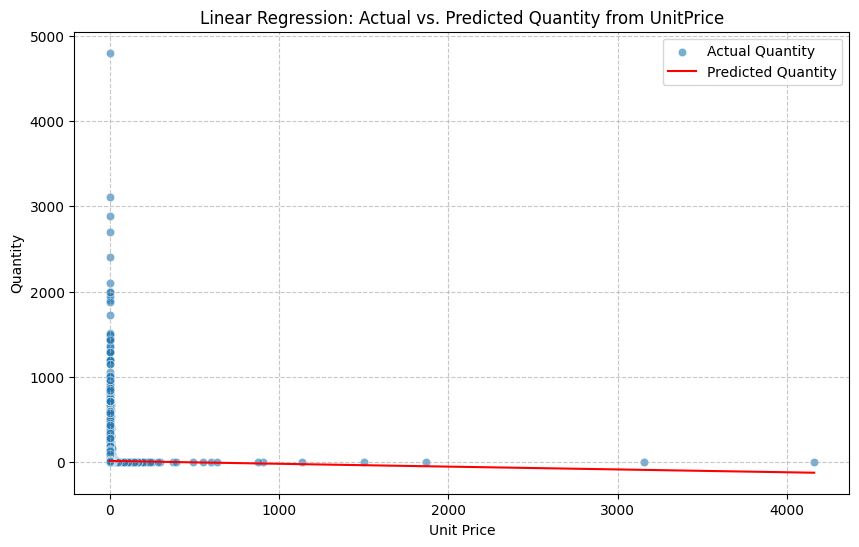

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_reg['UnitPrice'], y=y_test_reg, alpha=0.6, label='Actual Quantity')
sns.lineplot(x=X_test_reg['UnitPrice'], y=y_pred_reg, color='red', label='Predicted Quantity')
plt.title('Linear Regression: Actual vs. Predicted Quantity from UnitPrice')
plt.xlabel('Unit Price')
plt.ylabel('Quantity')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

#### Interpretation of Linear Regression Results

The evaluation metrics (MAE, MSE, R-squared) and the scatter plot will show how well 'UnitPrice' can predict 'Quantity'. It's important to note that a single feature like 'UnitPrice' might not be sufficient to accurately predict 'Quantity' due to other influencing factors (e.g., product type, promotions, customer behavior). This exercise primarily demonstrates the application of a regression model.

### 4.5 Anomaly Detection: Identifying Outliers in Quantity using Isolation Forest

Isolation Forest is an unsupervised machine learning algorithm for anomaly detection. It works by isolating observations instead of profiling normal observations. Anomalies are points that are few and different, making them more susceptible to isolation.

In [ ]:
from sklearn.ensemble import IsolationForest

# Select the 'Quantity' column for anomaly detection
X_if = processed_df[['Quantity']]

# Initialize the Isolation Forest model
# contamination: the proportion of outliers in the dataset. Default is 'auto'.
# We can set a value based on prior knowledge or let the model estimate.
# For demonstration, let's assume a contamination of 1% (0.01)
isolation_forest = IsolationForest(random_state=42, contamination=0.01)

# Fit the model
isolation_forest.fit(X_if)

# Predict anomalies (-1 for outliers, 1 for inliers)
processed_df['anomaly_score_quantity'] = isolation_forest.decision_function(X_if)
processed_df['is_anomaly_quantity'] = isolation_forest.predict(X_if)

print("Isolation Forest applied to Quantity:")
print(processed_df['is_anomaly_quantity'].value_counts())

print("\nTop 10 most anomalous quantities (lowest anomaly scores):")
display(processed_df.sort_values(by='anomaly_score_quantity', ascending=True).head(10)[['Quantity', 'anomaly_score_quantity', 'is_anomaly_quantity']])

Isolation Forest applied to Quantity:
is_anomaly_quantity
 1    393994
-1      3890
Name: count, dtype: int64

Top 10 most anomalous quantities (lowest anomaly scores):


,Quantity,anomaly_score_quantity,is_anomaly_quantity
16435,1008,-0.096331,-1
16428,972,-0.096331,-1
206121,4300,-0.096331,-1
52711,3114,-0.096331,-1
52710,2000,-0.096331,-1
52709,1930,-0.096331,-1
347563,1788,-0.096331,-1
383960,1296,-0.096331,-1
86503,1296,-0.096331,-1
490502,1600,-0.096331,-1


#### Visualizing Quantity Anomalies

Let's visualize the distribution of 'Quantity' and highlight the identified anomalies.

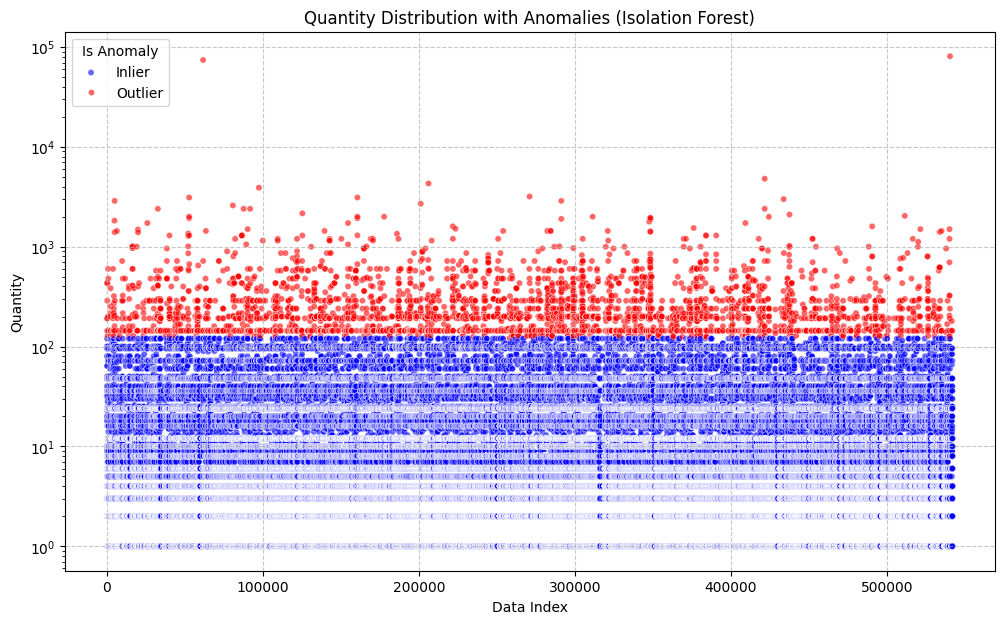

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(x=processed_df.index, y='Quantity', hue='is_anomaly_quantity', data=processed_df,
                palette={1: 'blue', -1: 'red'}, s=20, alpha=0.6)
plt.title('Quantity Distribution with Anomalies (Isolation Forest)')
plt.xlabel('Data Index')
plt.ylabel('Quantity')
plt.yscale('log') # Use log scale for better visualization if quantities vary widely
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Is Anomaly', labels=['Inlier', 'Outlier'])
plt.show()

#### Interpretation of Isolation Forest Results

The Isolation Forest model has identified a set of data points as anomalies (labeled -1) in the 'Quantity' column. These are likely instances where the number of items purchased is significantly different from the norm. The scatter plot helps to visually confirm these outliers. Further investigation into these anomalous transactions could reveal interesting insights or potential data errors.